In [1]:
# import cdsapi
# from dotenv import load_dotenv

# load_dotenv()

# c = cdsapi.Client()

# c.retrieve(
#     "reanalysis-era5-land",
#     {
#         "variable": [
#             "volumetric_soil_water_layer_1",  # 0-7cm
#             "volumetric_soil_water_layer_2",  # 7-28cm
#         ],
#         "year": [str(y) for y in range(2000, 2011)],
#         "month": [f"{m:02d}" for m in range(1, 13)],
#         "day": [f"{d:02d}" for d in range(1, 32)],
#         "time": "06:00",
#         "area": [14.0, 11.5, 10.0, 15],  # [N, W, S, E] - Borno only
#         "data_format": "grib",
#         "download_format": "unarchived"
#     },
#     "era5_land_soilmoisture_nigeria_2000-2010.grib"
# )

# ERA5 Soil Moisture — Borno State LGAs

Explores whether ERA5-Land antecedent soil moisture is a useful co-indicator for riverine flooding in selected Borno state LGAs. ERA5 volumetric soil water layers 1 (0–7 cm) and 2 (7–28 cm) are combined with Floodscan observations and IMERG precipitation to assess soil moisture conditions before, during, and outside flood events.

## Data download

The ERA5-Land grib files were downloaded from the Copernicus Climate Data Store (CDS) using `cdsapi` and uploaded to blob storage. The download code is preserved below for reference.

In [2]:
import os
import tempfile
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # noqa: F401 — registers .rio accessor
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import ocha_stratus as stratus
from exactextract import exact_extract
from scipy import stats as scipy_stats
from scipy.stats import mannwhitneyu

## Load ERA5 soil moisture

Two grib files are loaded from blob storage and opened via `cfgrib`: one covering 2010–2025 and one covering 2000–2010. Both contain `swvl1` (0–7 cm) and `swvl2` (7–28 cm) at 0.1° resolution and daily 06:00 UTC timesteps over a bounding box covering the Borno state area of interest.

In [3]:
def _open_era5_grib(blob_name):
    """Download an ERA5 grib blob and open as an xarray Dataset via cfgrib."""
    raw = stratus.azure_blob.load_blob_data(blob_name)
    with tempfile.NamedTemporaryFile(suffix=".grib", delete=False) as tmp:
        tmp.write(raw)
        tmp_path = tmp.name
    try:
        return xr.merge(
            [
                xr.open_dataset(tmp_path, engine="cfgrib", filter_by_keys={"shortName": v})
                .drop_vars("depthBelowLandLayer")
                for v in ["swvl1", "swvl2"]
            ],
            compat="override",
        )
    finally:
        os.unlink(tmp_path)

ds = _open_era5_grib("ds-aa-nga-flooding/raw/era5/era5_land_soilmoisture_nigeria.grib")
ds

<xarray.Dataset> Size: 69MB
Dimensions:     (time: 5844, latitude: 41, longitude: 36)
Coordinates:
  * time        (time) datetime64[ns] 47kB 2010-01-01T06:00:00 ... 2025-12-31...
    valid_time  (time) datetime64[ns] 47kB ...
  * latitude    (latitude) float64 328B 14.0 13.9 13.8 13.7 ... 10.2 10.1 10.0
  * longitude   (longitude) float64 288B 11.5 11.6 11.7 11.8 ... 14.8 14.9 15.0
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
Data variables:
    swvl1       (time, latitude, longitude) float32 35MB ...
    swvl2       (time, latitude, longitude) float32 35MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-22T13:26 GRIB to CDM+CF via cfgrib-0.9.1...

## Spatial overview

Annual mean of `swvl1` plotted across the ERA5 grid, with the four selected LGA boundaries overlaid. Confirms spatial coverage is sufficient to derive zonal statistics for each LGA.

In [4]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")

In [5]:
PCODES = ['NG008008', 'NG008015', 'NG008019', 'NG008025']

gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)
gdf_sel = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(PCODES)].to_crs("EPSG:4326")

# Annual mean of swvl1
da_mean = ds["swvl1"].mean(dim="time")

fig, ax = plt.subplots(figsize=(7, 6))

da_mean.plot(
    ax=ax,
    cmap="YlGnBu",
    cbar_kwargs={"label": "Volumetric soil water layer 1 (m³/m³)", "shrink": 0.8},
)

gdf_sel.boundary.plot(ax=ax, color="#E63946", linewidth=1.5)

for _, row in gdf_sel.iterrows():
    ax.annotate(
        row["ADM2_EN"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center", va="center", fontsize=8, color="#E63946", fontweight="bold",
    )

ax.set_title("ERA5-Land soil moisture — swvl1 (2025 annual mean) with selected LGAs", fontsize=11)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/tmprvgtruol.grib'

## Zonal statistics per LGA

Daily zonal statistics (`mean`, `median`, `min`, `max`, `sum`, `count`, `std`) of `swvl1` and `swvl2` are extracted for each selected LGA using `exactextract`, producing a tidy long-format dataframe with one row per (LGA, date, variable).

In [ ]:
dfs = []

for var in ["swvl1", "swvl2"]:
    da = (
        ds[var]
        .rio.write_crs("EPSG:4326")
        .rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    )
    times = pd.to_datetime(da.time.values).normalize()

    df_wide = exact_extract(
        da,
        gdf_sel,
        ops=["mean", "median", "min", "max", "sum", "count", "stdev"],
        include_cols=["ADM2_PCODE"],
        output="pandas",
    )

    band_cols = [c for c in df_wide.columns if c.startswith("band_")]
    df_long = (
        df_wide
        .melt(id_vars="ADM2_PCODE", value_vars=band_cols, var_name="band_stat", value_name="value")
        .assign(
            band=lambda d: d["band_stat"].str.extract(r"band_(\d+)_").astype(int),
            stat=lambda d: d["band_stat"].str.extract(r"band_\d+_(\w+)"),
        )
        .drop(columns="band_stat")
        .assign(valid_date=lambda d: d["band"].map({i + 1: t for i, t in enumerate(times)}))
        .drop(columns="band")
        .pivot_table(index=["ADM2_PCODE", "valid_date"], columns="stat", values="value")
        .reset_index()
        .rename(columns={"ADM2_PCODE": "pcode", "stdev": "std"})
        .assign(iso3="NGA", adm_level=2, variable=var)
    )
    dfs.append(df_long)

df_era5 = pd.concat(dfs, ignore_index=True)[
    ["iso3", "pcode", "valid_date", "adm_level", "variable",
     "mean", "median", "min", "max", "sum", "count", "std"]
]
df_era5

## Analysis dataset

Merges ERA5 soil moisture (2000–2025), Floodscan SFED (3-day rolling mean), and IMERG 10-day cumulative precipitation into a common panel. Flood events are loaded from the central event catalogue produced in notebook `00_flood_events`.

In [ ]:
FLOOD_MONTHS = range(6, 12)
LGA_COLORS   = ["#007CE0", "#F2645A", "#1EBFB3", "#F77F00"]
FLOOD_COLOR, NOFLOOD_COLOR = "#F2645A", "#CCCCCC"
LGA_NAMES = {
    p: gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == p, "ADM2_EN"].iloc[0] for p in PCODES
}

def era5_daily_means(ds_in, gdf):
    """Return daily zonal mean swvl1/swvl2 per polygon as a tidy DataFrame."""
    parts = []
    for var in ("swvl1", "swvl2"):
        da = (
            ds_in[var]
            .rio.write_crs("EPSG:4326")
            .rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
        )
        times = pd.to_datetime(da.time.values).normalize()
        df_wide = exact_extract(da, gdf, ops=["mean"], include_cols=["ADM2_PCODE"], output="pandas")
        band_cols = [c for c in df_wide.columns if c.startswith("band_")]
        df_var = (
            df_wide.rename(columns={"ADM2_PCODE": "pcode"})[["pcode"] + band_cols]
            .rename(columns={c: times[int(c.split("_")[1]) - 1] for c in band_cols})
            .melt(id_vars="pcode", var_name="valid_date", value_name=var)
        )
        parts.append(df_var.set_index(["pcode", "valid_date"]))
    return pd.concat(parts, axis=1).reset_index()

# ERA5: concatenate 2000-2010 and 2010-2025 into one daily SM dataframe
ds_early = _open_era5_grib("ds-aa-nga-flooding/raw/era5/era5_land_soilmoisture_nigeria_2000-2010.grib")

df_sm = (
    pd.concat([era5_daily_means(ds_early, gdf_sel), era5_daily_means(ds, gdf_sel)])
    .drop_duplicates(subset=["pcode", "valid_date"])
    .sort_values(["pcode", "valid_date"])
    .reset_index(drop=True)
)

# Floodscan with 3-day rolling average (used to anchor non-flood year windows)
df_fs = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet"
)
df_fs = df_fs[df_fs["pcode"].isin(PCODES)].copy()
df_fs["date"] = pd.to_datetime(df_fs["valid_date"]).dt.normalize()
df_fs = df_fs.sort_values(["pcode", "date"])
df_fs["sfed"] = df_fs.groupby("pcode")["mean"].transform(lambda x: x.rolling(3, min_periods=1).mean())

# IMERG: 10-day cumulative preceding each day
df_pr = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/imerg/imerg_hfr_lgas_borno.parquet"
)
df_pr = df_pr[df_pr["pcode"].isin(PCODES)].copy()
df_pr["date"] = pd.to_datetime(df_pr["valid_date"]).dt.normalize()
df_pr = df_pr.rename(columns={"mean": "precip"}).sort_values(["pcode", "date"])
df_pr["precip_10d"] = df_pr.groupby("pcode")["precip"].transform(
    lambda x: x.rolling(10, min_periods=1).sum().shift(1)
)

print(f"ERA5: {df_sm['valid_date'].min().date()} – {df_sm['valid_date'].max().date()}")
print(f"IMERG: {df_pr['date'].min().date()} – {df_pr['date'].max().date()}")

### Event-level exploratory analysis

Rather than using one observation per year, we identify each individual RP-3 exceedance **event** and extract the conditions at that event:

- **Antecedent soil moisture**: mean swvl1/swvl2 in the 14 days *before* event onset — captures pre-event catchment wetness
- **Concurrent IMERG**: maximum 10-day cumulative rainfall during the event window — captures the rainfall forcing

Two diagnostic plots follow:
1. **Scatter of IMERG vs. antecedent soil moisture**, coloured by flood intensity — shows whether the largest events require *both* signals to be elevated, or whether rainfall alone explains magnitude
2. **Lead-time correlation** — how the correlation between antecedent swvl1 and flood peak changes as we look further back before event onset

In [ ]:
# Load flood events from the central parquet (defined in 00_flood_events.ipynb)
PRE_DAYS = 14  # antecedent window before event onset

df_events_exp = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan_rp3_events.parquet"
)

# Reconstruct sfed_thresh dict from the parquet (one threshold per LGA)
sfed_thresh = df_events_exp.drop_duplicates("pcode").set_index("pcode")["sfed_thresh"].to_dict()

# For each event extract:
#   swvl1_pre / swvl2_pre — mean soil moisture in PRE_DAYS before event onset
#   imerg_max             — max 10d cumulative IMERG during event + pre-window
ev_rows = []
for _, ev in df_events_exp.iterrows():
    pcode = ev["pcode"]
    pre_start = ev["event_start"] - pd.Timedelta(days=PRE_DAYS)

    sm_pre = df_sm[
        (df_sm["pcode"] == pcode) &
        (df_sm["valid_date"] >= pre_start) &
        (df_sm["valid_date"] < ev["event_start"])
    ]
    pr_win = df_pr[
        (df_pr["pcode"] == pcode) &
        (df_pr["date"] >= pre_start) &
        (df_pr["date"] <= ev["event_end"])
    ]
    ev_rows.append({
        **ev,
        "swvl1_pre": sm_pre["swvl1"].mean() if not sm_pre.empty else np.nan,
        "swvl2_pre": sm_pre["swvl2"].mean() if not sm_pre.empty else np.nan,
        "imerg_max": pr_win["precip_10d"].max() if not pr_win.empty else np.nan,
        "sfed_norm": ev["peak_sfed"] / sfed_thresh[pcode],
    })

df_ev_feat = pd.DataFrame(ev_rows)
print(f"{len(df_ev_feat)} events across {len(PCODES)} LGAs")
df_ev_feat[["lga", "year", "peak_sfed", "sfed_norm", "swvl1_pre", "imerg_max"]].head(8)

In [ ]:
vmin = df_ev_feat["sfed_norm"].quantile(0.05)
vmax = df_ev_feat["sfed_norm"].quantile(0.95)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

fig, axes = plt.subplots(2, 2, figsize=(11, 9), squeeze=False)

for ax, pcode in zip(axes.flatten(), PCODES):
    lga = LGA_NAMES[pcode]
    sub = df_ev_feat[df_ev_feat["pcode"] == pcode].dropna(subset=["swvl1_pre", "imerg_max"])

    ax.scatter(
        sub["imerg_max"], sub["swvl1_pre"],
        c=sub["sfed_norm"], cmap=cmap, norm=norm,
        s=90, edgecolors="white", linewidth=0.8, zorder=3,
    )
    for _, row in sub.iterrows():
        ax.annotate(str(int(row["year"])), (row["imerg_max"], row["swvl1_pre"]),
                    textcoords="offset points", xytext=(4, 3), fontsize=7, color="#555555")

    ax.set_xlabel("IMERG 10d max in event window (mm)", fontsize=9)
    ax.set_ylabel("swvl1 mean — 14d before onset (m³/m³)", fontsize=9)
    ax.set_title(lga, fontsize=11)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

cb = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap), ax=axes.ravel().tolist(), shrink=0.55, pad=0.04
)
cb.set_label("SFED peak / RP-3 threshold (flood intensity)", fontsize=9)
fig.suptitle(
    "Conditions at each RP-3 exceedance event\n"
    "Do the most intense floods (dark) require both high rainfall and wet soils?",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("figures/event_conditions_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## Scatter: IMERG vs. antecedent soil moisture

At each RP-3 exceedance event, plots antecedent soil moisture (14-day pre-event mean of `swvl1`) against the maximum 10-day cumulative IMERG during the event window, coloured by flood intensity. If soil moisture contributes independently, the largest events should cluster in the top-right — requiring both high rainfall and wet soils.

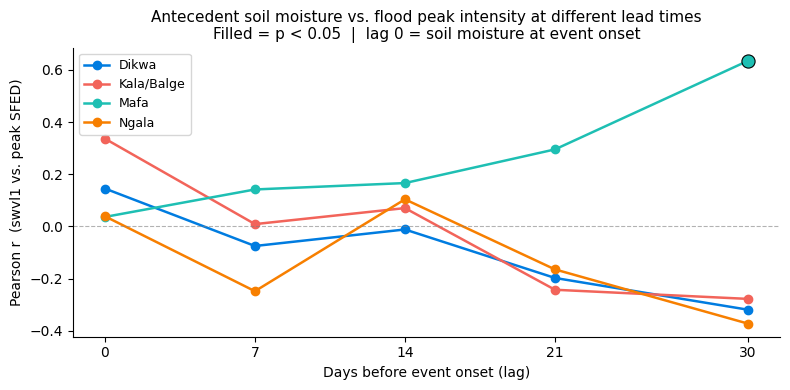

In [ ]:
# Lead-time correlation: how does antecedent swvl1 correlate with peak SFED
# at different lags before event onset?
# A strong positive r at lag > 0 suggests pre-event wetness matters independently.
# Filled markers = p < 0.05.
from scipy import stats as scipy_stats

LAGS   = [0, 7, 14, 21, 30]  # days before event onset
WINDOW = 7                    # days of soil moisture averaging at each lag

lag_records = []
for pcode in PCODES:
    sm_lga = df_sm[df_sm["pcode"] == pcode].set_index("valid_date")
    evs = df_ev_feat[df_ev_feat["pcode"] == pcode].dropna(subset=["peak_sfed"])

    for lag in LAGS:
        sm_vals = []
        for _, ev in evs.iterrows():
            lag_end   = ev["event_start"] - pd.Timedelta(days=lag)
            lag_start = lag_end - pd.Timedelta(days=WINDOW)
            win = sm_lga.loc[lag_start:lag_end, "swvl1"]
            sm_vals.append(win.mean() if not win.empty else np.nan)

        valid = evs.assign(sm_lag=sm_vals).dropna(subset=["sm_lag"])
        if len(valid) >= 3:
            r, p = scipy_stats.pearsonr(valid["sm_lag"], valid["peak_sfed"])
        else:
            r, p = np.nan, np.nan
        lag_records.append({"pcode": pcode, "lga": LGA_NAMES[pcode], "lag_days": lag, "r": r, "p": p})

df_lag_corr = pd.DataFrame(lag_records)

fig, ax = plt.subplots(figsize=(8, 4))
for pcode, color in zip(PCODES, LGA_COLORS):
    sub = df_lag_corr[df_lag_corr["pcode"] == pcode].sort_values("lag_days")
    ax.plot(sub["lag_days"], sub["r"], marker="o", color=color,
            linewidth=1.8, markersize=6, label=LGA_NAMES[pcode])
    sig = sub[sub["p"] < 0.05]
    if not sig.empty:
        ax.scatter(sig["lag_days"], sig["r"], color=color, s=90,
                   zorder=4, edgecolors="black", linewidth=0.8)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Days before event onset (lag)", fontsize=10)
ax.set_ylabel("Pearson r  (swvl1 vs. peak SFED)", fontsize=10)
ax.set_xticks(LAGS)
ax.set_title(
    "Antecedent soil moisture vs. flood peak intensity at different lead times\n"
    "Filled = p < 0.05  |  lag 0 = soil moisture at event onset",
    fontsize=11,
)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/swvl1_lag_correlation.png", dpi=300)
plt.show()

## Lead-time correlation

Pearson correlation between antecedent `swvl1` and flood peak intensity (SFED / RP-3 threshold) at increasing lead times before event onset (0, 7, 14, 21, 30 days). Filled markers indicate statistical significance (p < 0.05). A strong positive correlation at longer lags would suggest pre-event soil wetness contributes independently of rainfall forcing.

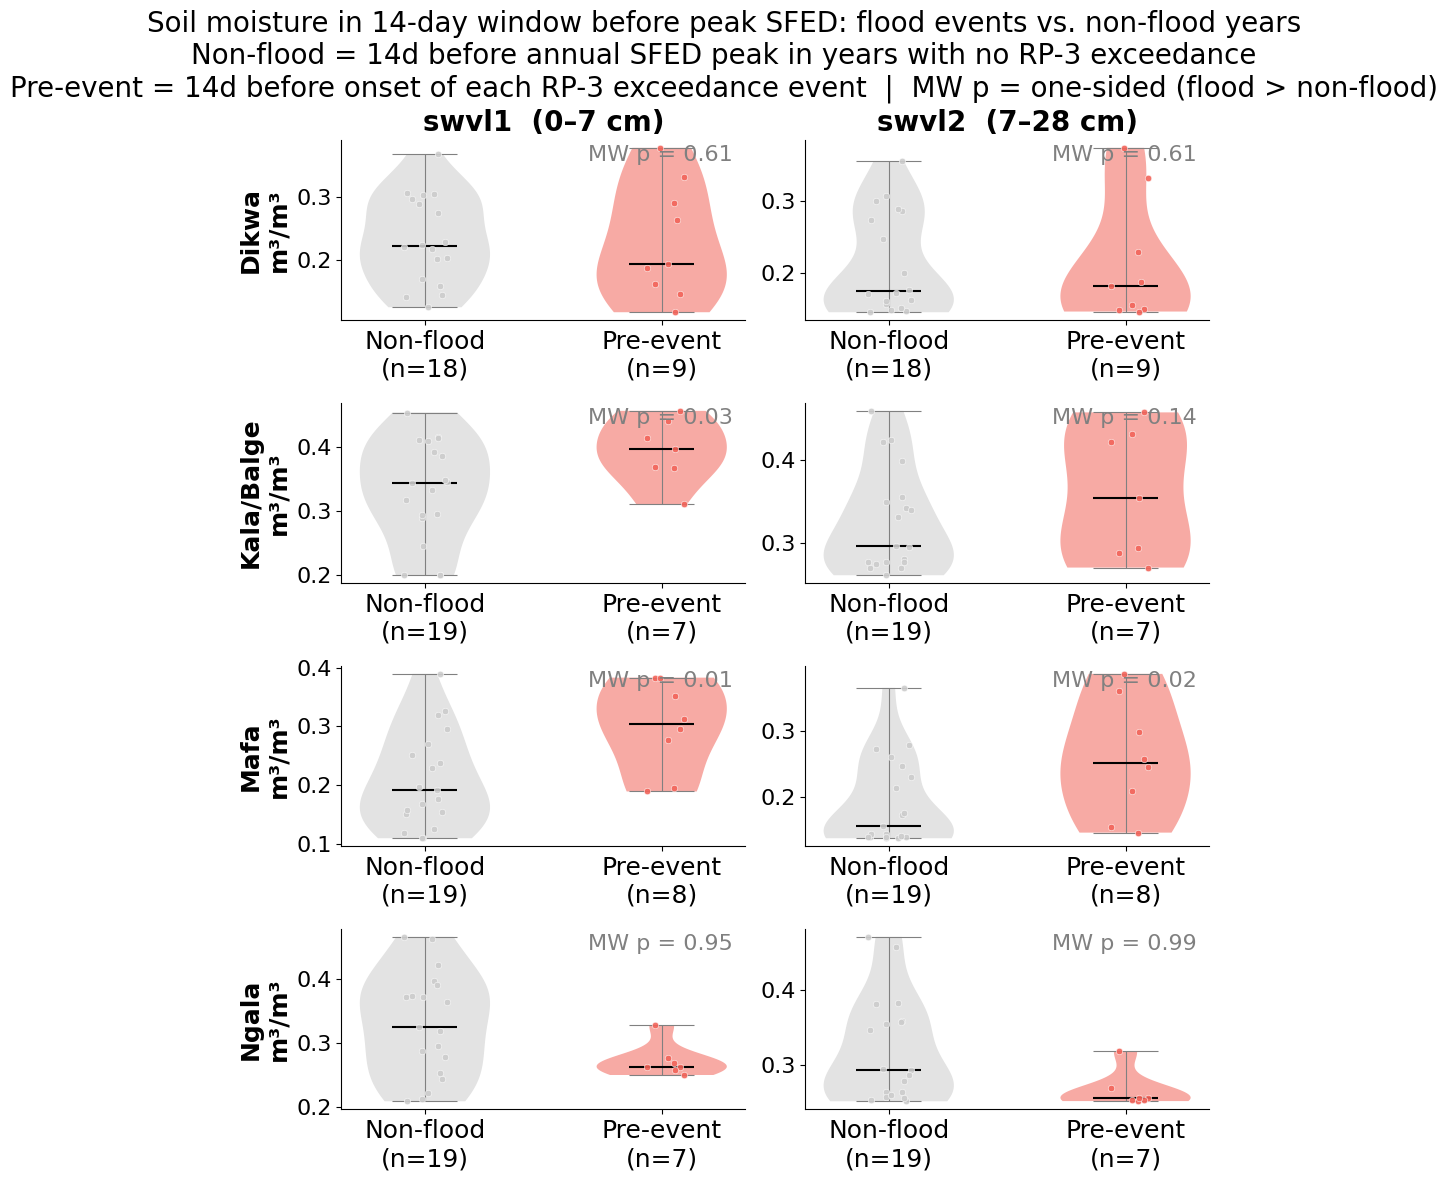

In [ ]:
from scipy.stats import mannwhitneyu

# --- Build reference distribution for non-flood years ---
# For symmetry with the flood case, we anchor the same 14-day window to the date of
# peak SFED in each non-flood year — the moment flooding came closest to occurring.
# Non-flood year: no day in Jun–Nov had SFED ≥ RP-3 threshold.
flood_year_sets = {pcode: set(df_ev_feat[df_ev_feat["pcode"] == pcode]["year"]) for pcode in PCODES}

nonflood_rows = []
for pcode in PCODES:
    thresh = sfed_thresh[pcode]
    fy = flood_year_sets[pcode]
    df_p = df_fs[
        (df_fs["pcode"] == pcode) &
        (df_fs["date"].dt.month.isin(FLOOD_MONTHS)) &
        (~df_fs["date"].dt.year.isin(fy))
    ].copy()
    df_p["year"] = df_p["date"].dt.year

    # Peak SFED date per non-flood year
    peak_dates = df_p.loc[df_p.groupby("year")["sfed"].idxmax(), ["year", "date"]].reset_index(drop=True)

    for _, row in peak_dates.iterrows():
        peak_date = row["date"]
        pre_start = peak_date - pd.Timedelta(days=PRE_DAYS)
        sm_win = df_sm[
            (df_sm["pcode"] == pcode) &
            (df_sm["valid_date"] >= pre_start) &
            (df_sm["valid_date"] < peak_date)
        ]
        nonflood_rows.append({
            "pcode": pcode, "lga": LGA_NAMES[pcode],
            "year": int(row["year"]),
            "swvl1": sm_win["swvl1"].mean() if not sm_win.empty else np.nan,
            "swvl2": sm_win["swvl2"].mean() if not sm_win.empty else np.nan,
        })

df_nonflood = pd.DataFrame(nonflood_rows).dropna(subset=["swvl1"])

# --- Plot: 4 LGAs × 2 soil moisture layers ---
fig, axes = plt.subplots(len(PCODES), 2, figsize=(10, 12), squeeze=False)

for row, pcode in enumerate(PCODES):
    lga = LGA_NAMES[pcode]

    for col, (var, layer_label) in enumerate([
        ("swvl1", "swvl1  (0–7 cm)"),
        ("swvl2", "swvl2  (7–28 cm)"),
    ]):
        ax = axes[row, col]

        nf_vals = df_nonflood[df_nonflood["pcode"] == pcode][var].dropna().values
        fl_vals = df_ev_feat[df_ev_feat["pcode"] == pcode][f"{var}_pre"].dropna().values

        vp = ax.violinplot([nf_vals, fl_vals], positions=[1, 2],
                           showmedians=True, widths=0.55)
        for body, color in zip(vp["bodies"], [NOFLOOD_COLOR, FLOOD_COLOR]):
            body.set_facecolor(color)
            body.set_alpha(0.55)
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(1.5)
        for part in ["cbars", "cmins", "cmaxes"]:
            vp[part].set_color("gray")
            vp[part].set_linewidth(0.8)

        rng = np.random.default_rng(42)
        for x_pos, vals, color in [(1, nf_vals, NOFLOOD_COLOR), (2, fl_vals, FLOOD_COLOR)]:
            ax.scatter(rng.uniform(x_pos - 0.1, x_pos + 0.1, size=len(vals)),
                       vals, color=color, s=22, alpha=0.9, zorder=3,
                       edgecolors="white", linewidth=0.4)

        if len(nf_vals) >= 3 and len(fl_vals) >= 3:
            _, p = mannwhitneyu(fl_vals, nf_vals, alternative="greater")
            ax.text(0.97, 0.97, f"MW p = {p:.2f}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=16, color="gray")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            [f"Non-flood\n(n={len(nf_vals)})", f"Pre-event\n(n={len(fl_vals)})"],
            fontsize=18,
        )
        ax.tick_params(axis="y", labelsize=16)
        ax.spines[["top", "right"]].set_visible(False)

        if row == 0:
            ax.set_title(layer_label, fontsize=20, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{lga}\nm³/m³", fontsize=18, fontweight="bold")

fig.suptitle(
    "Soil moisture in 14-day window before peak SFED: flood events vs. non-flood years\n"
    "Non-flood = 14d before annual SFED peak in years with no RP-3 exceedance\n"
    "Pre-event = 14d before onset of each RP-3 exceedance event  |  MW p = one-sided (flood > non-flood)",
    fontsize=20,
)
plt.tight_layout()
plt.savefig("figures/swvl_flood_vs_nonflood.png", dpi=300)
plt.show()

## Flood vs. non-flood soil moisture

Compares soil moisture in the 14-day window before peak SFED between flood years (RP-3 exceedance events) and non-flood years (anchored to the annual SFED peak date in years with no exceedance). Mann-Whitney U test (one-sided: flood > non-flood) assesses whether the difference is statistically significant.

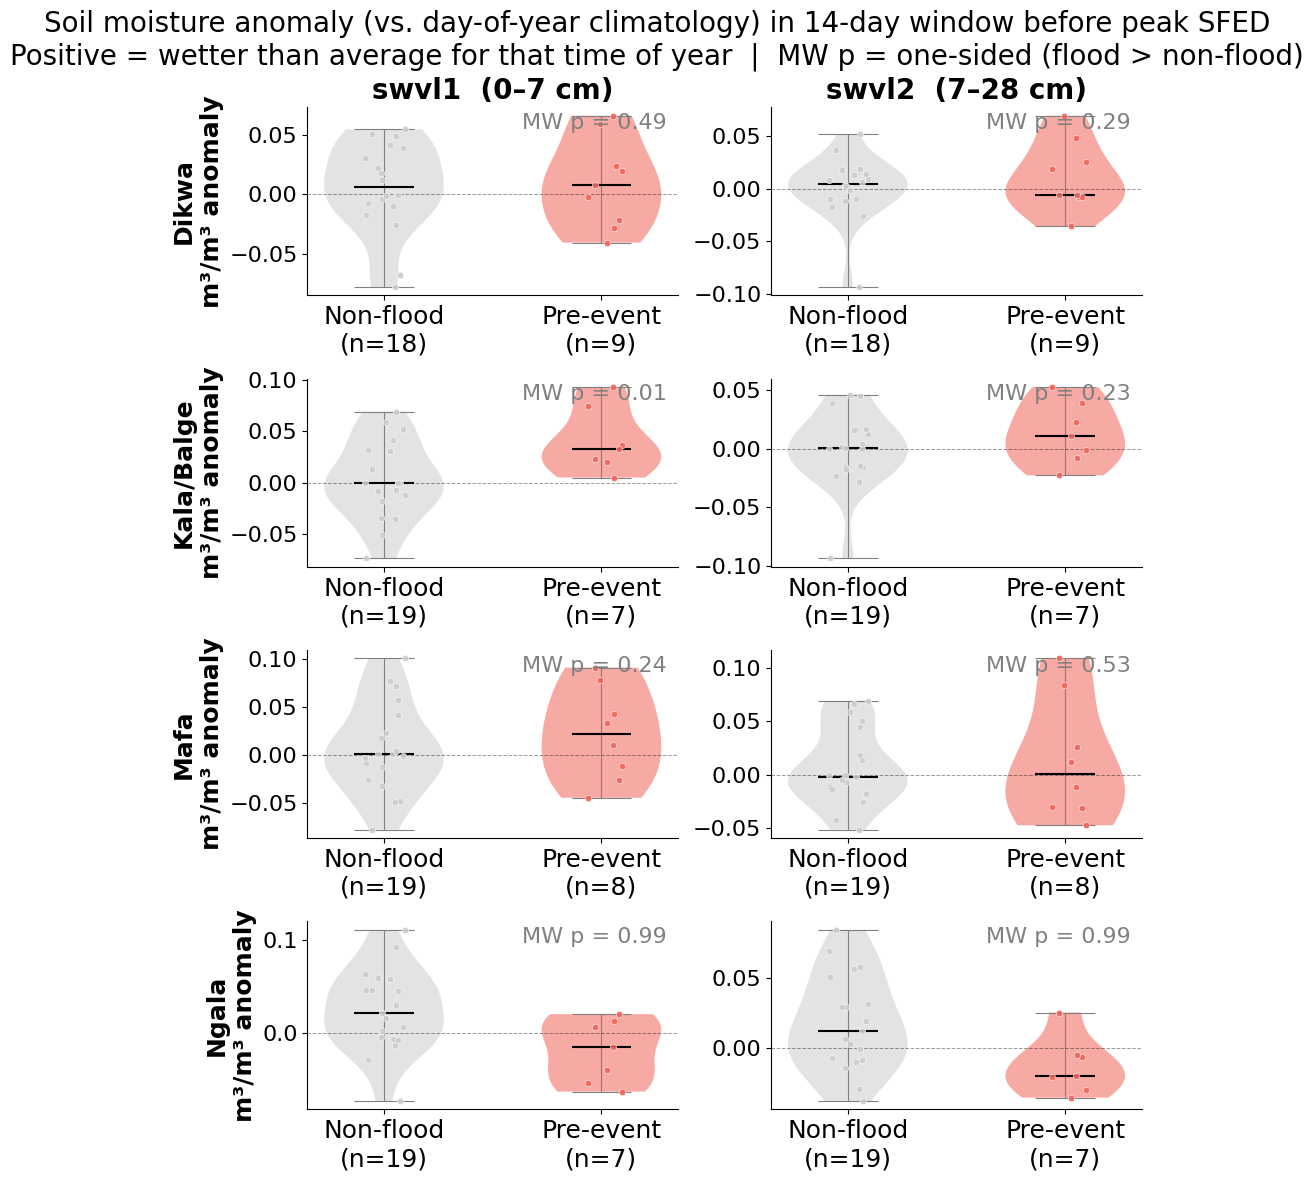

In [ ]:
# Soil moisture anomaly distributions
# Removes the seasonal cycle so we can see whether soils were unusually wet
# before flood events, not just at their climatological peak.

from scipy.stats import mannwhitneyu

# Day-of-year climatology across all available ERA5 years
df_sm_clim = (
    df_sm
    .assign(doy=lambda d: d["valid_date"].dt.dayofyear)
    .groupby(["pcode", "doy"])[["swvl1", "swvl2"]]
    .mean()
    .reset_index()
)

df_sm_a = (
    df_sm
    .assign(doy=lambda d: d["valid_date"].dt.dayofyear)
    .merge(df_sm_clim, on=["pcode", "doy"], suffixes=("", "_clim"))
    .assign(
        swvl1_anom=lambda d: d["swvl1"] - d["swvl1_clim"],
        swvl2_anom=lambda d: d["swvl2"] - d["swvl2_clim"],
    )
)

flood_year_sets = {
    pcode: set(df_events_exp[df_events_exp["pcode"] == pcode]["year"]) for pcode in PCODES
}

# Flood events: mean anomaly in PRE_DAYS window before event onset
flood_anom_rows = []
for _, ev in df_events_exp.iterrows():
    pcode = ev["pcode"]
    pre_start = ev["event_start"] - pd.Timedelta(days=PRE_DAYS)
    win = df_sm_a[
        (df_sm_a["pcode"] == pcode) &
        (df_sm_a["valid_date"] >= pre_start) &
        (df_sm_a["valid_date"] < ev["event_start"])
    ]
    flood_anom_rows.append({
        "pcode": pcode, "lga": ev["lga"],
        "swvl1_anom": win["swvl1_anom"].mean() if not win.empty else np.nan,
        "swvl2_anom": win["swvl2_anom"].mean() if not win.empty else np.nan,
    })
df_flood_anom = pd.DataFrame(flood_anom_rows).dropna(subset=["swvl1_anom"])

# Non-flood years: mean anomaly in PRE_DAYS window before peak SFED date
nonflood_anom_rows = []
for pcode in PCODES:
    fy = flood_year_sets[pcode]
    df_p = df_fs[
        (df_fs["pcode"] == pcode) &
        (df_fs["date"].dt.month.isin(FLOOD_MONTHS)) &
        (~df_fs["date"].dt.year.isin(fy))
    ].copy()
    df_p["year"] = df_p["date"].dt.year
    peak_dates = df_p.loc[df_p.groupby("year")["sfed"].idxmax(), ["year", "date"]].reset_index(drop=True)
    for _, row in peak_dates.iterrows():
        peak_date = row["date"]
        pre_start = peak_date - pd.Timedelta(days=PRE_DAYS)
        win = df_sm_a[
            (df_sm_a["pcode"] == pcode) &
            (df_sm_a["valid_date"] >= pre_start) &
            (df_sm_a["valid_date"] < peak_date)
        ]
        nonflood_anom_rows.append({
            "pcode": pcode, "lga": LGA_NAMES[pcode],
            "swvl1_anom": win["swvl1_anom"].mean() if not win.empty else np.nan,
            "swvl2_anom": win["swvl2_anom"].mean() if not win.empty else np.nan,
        })
df_nonflood_anom = pd.DataFrame(nonflood_anom_rows).dropna(subset=["swvl1_anom"])

# Plot
fig, axes = plt.subplots(len(PCODES), 2, figsize=(10, 12), squeeze=False)

for row, pcode in enumerate(PCODES):
    lga = LGA_NAMES[pcode]
    for col, (var, layer_label) in enumerate([
        ("swvl1_anom", "swvl1  (0–7 cm)"),
        ("swvl2_anom", "swvl2  (7–28 cm)"),
    ]):
        ax = axes[row, col]
        nf_vals = df_nonflood_anom[df_nonflood_anom["pcode"] == pcode][var].dropna().values
        fl_vals = df_flood_anom[df_flood_anom["pcode"] == pcode][var].dropna().values

        vp = ax.violinplot([nf_vals, fl_vals], positions=[1, 2], showmedians=True, widths=0.55)
        for body, color in zip(vp["bodies"], [NOFLOOD_COLOR, FLOOD_COLOR]):
            body.set_facecolor(color)
            body.set_alpha(0.55)
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(1.5)
        for part in ["cbars", "cmins", "cmaxes"]:
            vp[part].set_color("gray")
            vp[part].set_linewidth(0.8)

        rng = np.random.default_rng(42)
        for x_pos, vals, color in [(1, nf_vals, NOFLOOD_COLOR), (2, fl_vals, FLOOD_COLOR)]:
            ax.scatter(
                rng.uniform(x_pos - 0.1, x_pos + 0.1, size=len(vals)),
                vals, color=color, s=22, alpha=0.9, zorder=3,
                edgecolors="white", linewidth=0.4,
            )

        ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)

        if len(nf_vals) >= 3 and len(fl_vals) >= 3:
            _, p = mannwhitneyu(fl_vals, nf_vals, alternative="greater")
            ax.text(0.97, 0.97, f"MW p = {p:.2f}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=16, color="gray")

        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            [f"Non-flood\n(n={len(nf_vals)})", f"Pre-event\n(n={len(fl_vals)})"],
            fontsize=18,
        )
        ax.tick_params(axis="y", labelsize=16)
        ax.spines[["top", "right"]].set_visible(False)
        if row == 0:
            ax.set_title(layer_label, fontsize=20, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{lga}\nm³/m³ anomaly", fontsize=18, fontweight="bold")

fig.suptitle(
    "Soil moisture anomaly (vs. day-of-year climatology) in 14-day window before peak SFED\n"
    "Positive = wetter than average for that time of year  |  MW p = one-sided (flood > non-flood)",
    fontsize=20,
)
plt.tight_layout()
plt.savefig("figures/swvl_anomaly_flood_vs_nonflood.png", dpi=300)
plt.show()

## Soil moisture anomaly

Removes the seasonal cycle (day-of-year climatology across all ERA5 years) to isolate whether soils were *unusually wet* before flood events, independent of the climatological seasonal rise. Positive anomalies indicate soils were wetter than average for that time of year.

In [ ]:
# Conditional flood intensity scatter
# Given that an event occurred, does antecedent soil moisture predict how
# intense it gets? sfed_norm >= 1 for all events by definition.

from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 2, figsize=(11, 9), squeeze=False)

for ax, pcode in zip(axes.flatten(), PCODES):
    lga = LGA_NAMES[pcode]
    sub = df_ev_feat[df_ev_feat["pcode"] == pcode].dropna(subset=["swvl1_pre", "sfed_norm"])

    ax.scatter(
        sub["swvl1_pre"], sub["sfed_norm"],
        color="#007CE0", s=70, edgecolors="white", linewidth=0.6, zorder=3,
    )
    for _, row in sub.iterrows():
        ax.annotate(str(int(row["year"])), (row["swvl1_pre"], row["sfed_norm"]),
                    textcoords="offset points", xytext=(4, 3), fontsize=14, color="#555555")

    if len(sub) >= 3:
        r, p = scipy_stats.pearsonr(sub["swvl1_pre"], sub["sfed_norm"])
        m, b, _, _, _ = scipy_stats.linregress(sub["swvl1_pre"], sub["sfed_norm"])
        x_line = np.linspace(sub["swvl1_pre"].min(), sub["swvl1_pre"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.2, linestyle="--", zorder=2)
        p_str = "p<0.05" if p < 0.05 else f"p={p:.2f}"
        ax.text(0.97, 0.05, f"r={r:.2f}, {p_str}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=16,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.85))

    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xlabel("swvl1 mean — 14d before onset (m³/m³)", fontsize=18)
    ax.set_ylabel("Flood intensity (SFED / RP-3 threshold)", fontsize=18)
    ax.set_title(lga, fontsize=22)
    ax.tick_params(labelsize=16)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Does antecedent soil moisture predict flood intensity?\n"
    "All events ≥ RP-3  |  dashed = regression  |  dotted line = RP-3 threshold",
    fontsize=22, y=1.01,
)
plt.tight_layout()
plt.savefig("figures/swvl1_vs_intensity.png", dpi=300, bbox_inches="tight")
plt.show()

## Conditional flood intensity

Given that an RP-3 exceedance event occurred, tests whether antecedent `swvl1` predicts how intense the flooding becomes (SFED peak / RP-3 threshold). A positive correlation with a significant regression slope would support soil moisture as a conditioning factor for event severity.